# Sequences between locations

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import datetime as dt
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
sns.set(style="white", color_codes=True)
import warnings # current version of seaborn generates a bunch of warnings that we'll ignore
warnings.filterwarnings("ignore")

import plotly 

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [3]:
!pip install biopython

     |████████████████████████████████| 2.3MB 4.7MB/s 


In [4]:
!pip install phylo-treetime

     |████████████████████████████████| 133kB 4.5MB/s 


In [5]:
from Bio import AlignIO
from Bio.Align.Applications import ClustalOmegaCommandline
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from Bio.Phylo import draw
from Bio import SeqIO
from Bio import Phylo, AlignIO
import subprocess
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from Bio.Align.Applications import ClustalOmegaCommandline

read Alignmented file (MultipleSeqAlignment type)

In [204]:
align = AlignIO.read("/content/aln_woBat.fasta", "fasta")
print(align)
align

SingleLetterAlphabet() alignment with 23 rows and 29975 columns
--TAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...AAA MT415320.1
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...AAA MN908947.3
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...--- MT044257.1
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...--- MN988713.1
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...AAA MT374104.1
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...--- MT304475.1
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...--- MT304474.1
------GGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...--- MT637143.1
--TAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...AAA MT531537.2
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...--- MT066175.1
-------------------------------------AACTTTC...--- MT447154.1
--------------------------------------------...--- MT320891.2
----AAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...--- MT641710.1
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTC...--- MT318827.1
--------------------------------------ACTTTC...--- MT450949.1
------

<<class 'Bio.Align.MultipleSeqAlignment'> instance (23 records of length 29975, SingleLetterAlphabet()) at 7f60e46e1128>

In [82]:
align[1,:].description
long = len(align[1,:].seq)

In [ ]:
#array = [0:25,0:long]
for i in range(25):
  print(align[i,:].seq)

calculate distance

In [205]:
calculator = DistanceCalculator('identity')
dm = calculator.get_distance(align)

In [206]:
print(dm)

MT415320.1	0
MN908947.3	0.0003002502085071024	0
MT044257.1	0.0012343619683069518	0.0009341117597998494	0
MN988713.1	0.001267723102585494	0.0009674728940783917	0.0002668890742285601	0
MT374104.1	0.0005337781484570092	0.00023352793994990684	0.0011676396997497562	0.0012010008340284095	0
MT304475.1	0.0011676396997497562	0.0008673894912426539	0.0004003336113428402	0.00043369474562138244	0.0010341951626354762	0
MT304474.1	0.0011676396997497562	0.0008673894912426539	0.0004003336113428402	0.00043369474562138244	0.0010341951626354762	0.0	0
MT637143.1	0.0011676396997497562	0.001000834028356934	0.001000834028356934	0.0010341951626354762	0.0012343619683069518	0.0009341117597998494	0.0009341117597998494	0
MT531537.2	0.000500417014178467	0.00033361134278564464	0.001267723102585494	0.0013010842368640363	0.0005671392827356625	0.0012010008340284095	0.0012010008340284095	0.0007339449541284848	0
MT066175.1	0.0014678899082568586	0.0011676396997497562	0.0005671392827356625	0.0006672226855712893	0.001401167

### K - Clustering

In [209]:
# using distance
from Bio.Cluster import kmedoids 
clusterid, error,found = kmedoids(dm) 

print(clusterid)
#print(error)
#print(found)

[ 5  5  5  5  5  5  5  5  5  5 19 19  5  5 19 19 19 19 19 19 19 19 19]


### Hierarchical Clustering

In [210]:
from Bio.Cluster import treecluster 
cluster = treecluster(dm)
print(cluster)

(6, 5): 0
(21, 20): 3.29051e-09
(3, 2): 7.98432e-09
(19, 10): 3.09211e-08
(4, 0): 3.37761e-08
(-1, -3): 3.6244e-08
(1, -5): 4.7422e-08
(13, 9): 4.83898e-08
(14, 18): 8.10045e-08
(8, -7): 8.17788e-08
(11, -4): 8.64242e-08
(7, -6): 1.86446e-07
(-9, 16): 1.9264e-07
(15, -11): 2.82645e-07
(-8, -12): 3.43713e-07
(12, 17): 4.65994e-07
(-2, -13): 5.54015e-07
(-16, -14): 1.02432e-06
(-15, -10): 1.12782e-06
(-18, -17): 3.58651e-06
(-20, -19): 8.1636e-06
(22, -21): 1.44523e-05


Create the Phylogenetic Tree


Distance Matrix:
-----------------------
MT415320.1	0
MN908947.3	0.0003002502085071024	0
MT044257.1	0.0012343619683069518	0.0009341117597998494	0
MN988713.1	0.001267723102585494	0.0009674728940783917	0.0002668890742285601	0
MT374104.1	0.0005337781484570092	0.00023352793994990684	0.0011676396997497562	0.0012010008340284095	0
MT304475.1	0.0011676396997497562	0.0008673894912426539	0.0004003336113428402	0.00043369474562138244	0.0010341951626354762	0
MT304474.1	0.0011676396997497562	0.0008673894912426539	0.0004003336113428402	0.00043369474562138244	0.0010341951626354762	0.0	0
MT637143.1	0.0011676396997497562	0.001000834028356934	0.001000834028356934	0.0010341951626354762	0.0012343619683069518	0.0009341117597998494	0.0009341117597998494	0
MT531537.2	0.000500417014178467	0.00033361134278564464	0.001267723102585494	0.0013010842368640363	0.0005671392827356625	0.0012010008340284095	0.0012010008340284095	0.0007339449541284848	0
MT066175.1	0.0014678899082568586	0.0011676396997497562	0.00056713928

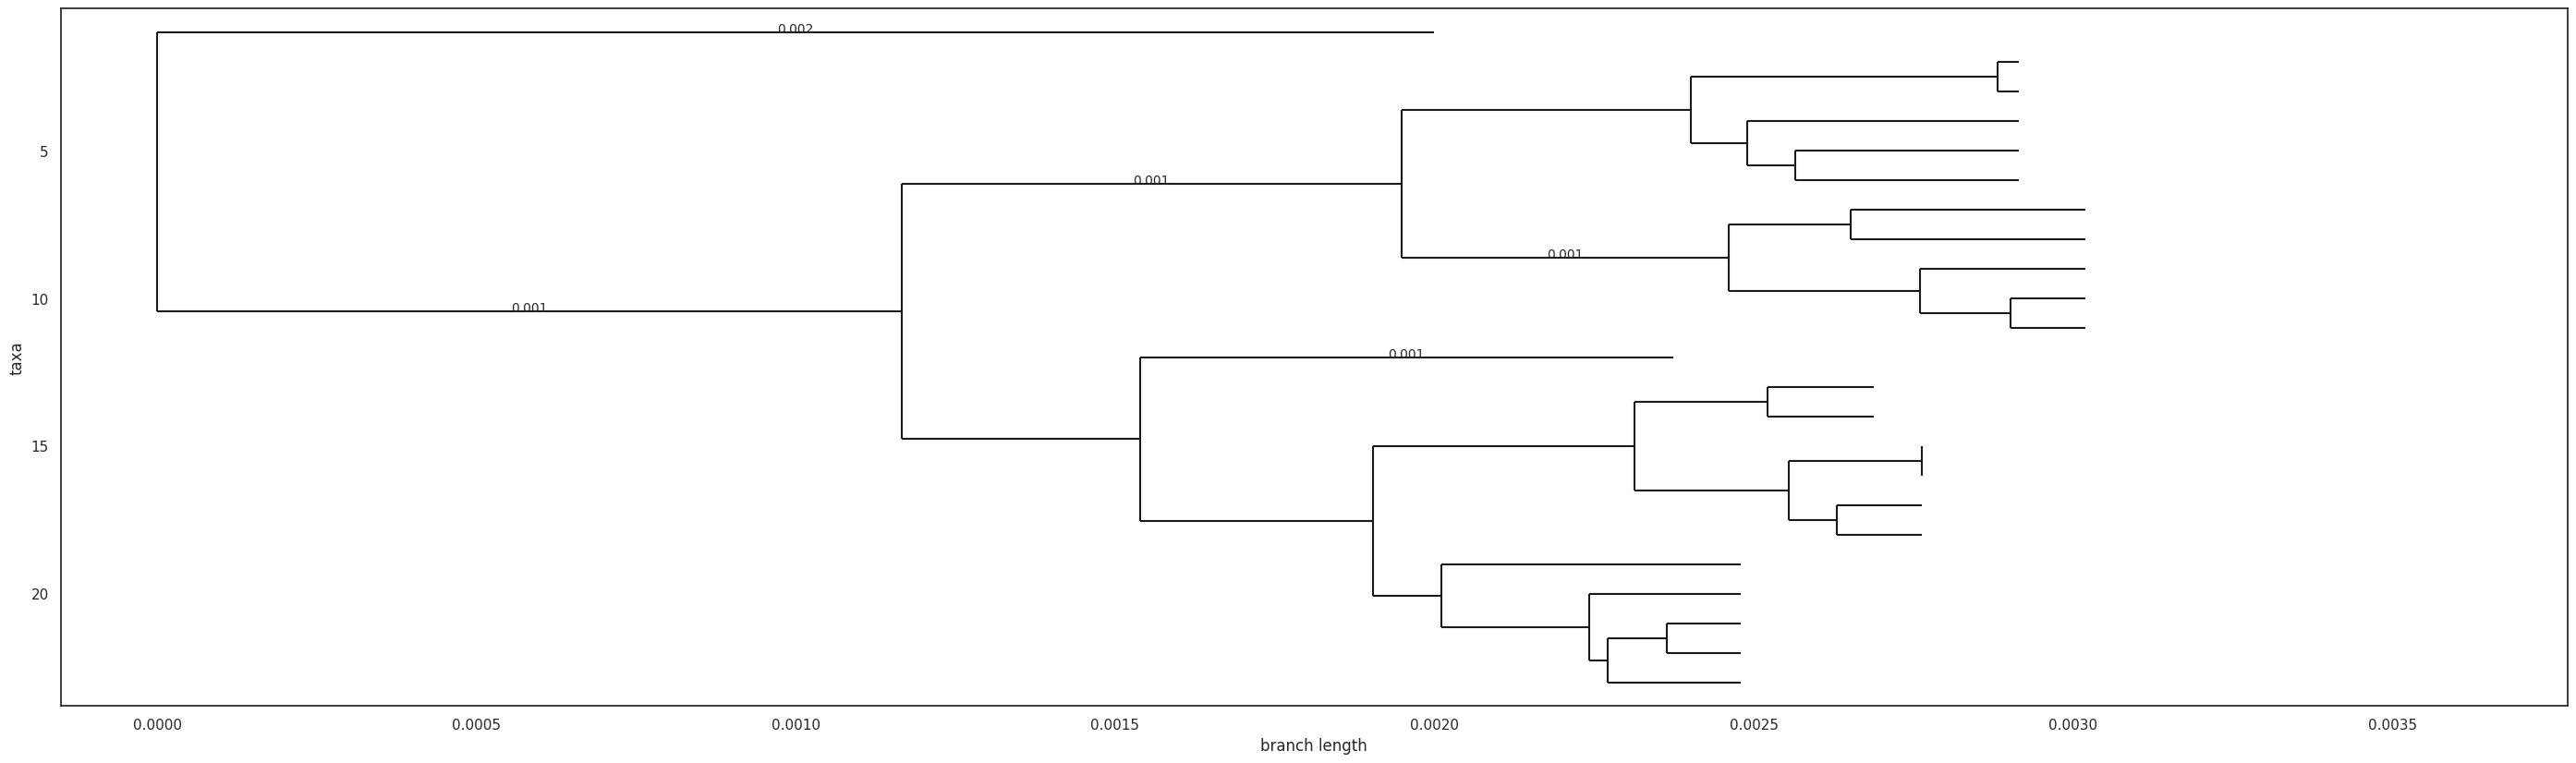

In [211]:
def get_label(leaf):
    code=['MN908947', 'MT066175', 'MT374104', 'MT044257', 'MN988713', 'MT318827', 'MT447154', 'MT447157', 
          'MT304474', 'MT304475', 'MT270101', 'MT292569', 'MT635445', 'MT528239','MT655131', 'MT531537', 'MT415320', 
          'MT320891', 'MT576034', 'MT637143', 'MT447177', 'MT641710', 'MT450949']
    country=['China', 'Taiwan', 'USA', 'USA2', 'Germany', 'Thailand', 'Thailand2', 'Korea', 'Korea2', 
             'Germany2', 'Spain', 'Russia', 'Italy', 'Spain', 'Italy2', 'India', 'Iran', 'India2', 'Russia2', 
             'Iran', 'Australia', 'Australia2']  #host
    
    if leaf.name.startswith('Inner'):
        name=''
        return name
    else:
        
        for i in range(0, len(code)):
            if leaf.name==code[i]:
                name=host[i]
                return name
            
            #return ''
        #name=leaf.name

    #return name


print('\nDistance Matrix:\n-----------------------')
print(dm)

# Phylogenetic tree using UPGMA algorithm
constructor = DistanceTreeConstructor()
tree = constructor.upgma(dm) # We color the human strain, SARS and SARS-CoV-2 in blue
#tree.clade[1, 1, 0].color = "black"
#mrca = tree.common_ancestor({'name':  'MG772934'}, {'name': 'MN996528'})
#mrca.color = "red"
#to_networkx(tree)

fig = plt.figure(figsize=(35, 10), dpi=100)
axes = fig.add_subplot(1, 1, 1)
#Phylo.draw(tree, axes=axes, label_func=get_label)
Phylo.draw(tree, axes=axes, label_func=get_label, branch_labels=lambda c: round(c.branch_length, 3), do_show=False) #lambda x:x.name.split('|')[0] if x.is_terminal() else ""
plt.savefig('tree.png')

print('\nPhylogenetic Tree:\n-----------------------')
Phylo.draw_ascii(tree, column_width=80)

read alignmented fasta into array

In [212]:
import sys

fasta = []
test = []
with open("aln_woBat.fasta") as file_one:
    for line in file_one:
        line = line.strip()
        if not line:
           continue
        if line.startswith(">"):
            active_sequence_name = line[1:]
            if active_sequence_name not in fasta:
                test.append(''.join(fasta))
                fasta = []
            continue
        sequence = line
        fasta.append(sequence)

# Flush the last fasta block to the test list
if fasta:
    test.append(''.join(fasta))

# Print the test list
#for i, row in enumerate(test):
#    print(i)
#    print(row)

In [216]:
# remove bat covid-19 sequence
matrix1 = test[1:]
#matrix2 = test[2:24]
matrix1

['--TAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCTGTTCTCTAAACGAACTTTAAAATCTGTGTGGCTGTCACTCGGCTGCATGCTTAGTGCACTCACGCAGTATAATTAATAACTA-ATTACTGTCGTTGACAGGACACGAGTAACTCGTCTATCTTCTGCAGGCTGCTTACGGTTTCGTCCGTGTTGCAGCCGATCATCAGCACATCTAGGTTTCGTCCGGGTGTGACCGAAAGGTAAGATGGAGAGCCTTGTCCCTGGTTTCAACGAGAAAACACACGTCCAACTCAGTTTGCCTGTTTTACAGGTTCGCGACGTGCTCGTACGTGGCTTTGGAGACTCCGTGGAGGAGGTCTTATCAGAGGCACGTCAACATCTTAAAGATGGCACTTGTGGCTTAGTAGAAGTTGAAAAAGGCGTTTTGCCTCAACTTGAACAGCCCTATGTGTTCATCAAACGTTCGGATGCTCGAACTGCACCTCATGGTCATGTTATGGTTGAGCTGGTAGCAGAACTCGAAGGCATTCAGTACGGTCGTAGTGGTGAGACACTTGGTGTCCTTGTCCCTCATGTGGGCGAAATACCAGTGGCTTACCGCAAGGTTCTTCTTCGTAAGAACGGTAATAAAGGAGCTGGTGGCCATAGTTACGGCGCCGATCTAAAGTCATTTGACTTAGGCGACGAGCTTGGCACTGATCCTTATGAAGATTTTCAAGAAAACTGGAACACTAAACATAGCAGTGGTGTTACCCGTGAACTCATGCGTGAGCTTAACGGAGGGGCATACACTCGCTATGTCGATAACAACTTCTGTGGCCCTGATGGCTACCCTCTTGAGTGCATTAAAGACCTTCTAGCACGTGCTGGTAAAGCTTCATGCACTTTGTCCGAACAACTGGACTTTATTGACACTAAGAGGGGTGTATACTGCTGCCGTGAACATGAGCATGAAATTGCTTGGTACACGGAACGT

In [217]:
matrix1 = np.asarray([np.fromstring(s, dtype=np.uint8) for s in matrix1])
#matrix2 = np.asarray([np.fromstring(s, dtype=np.uint8) for s in matrix2])

### K - Clustering

In [220]:
# using sequence
from Bio.Cluster import kcluster 
clusterid,error,found = kcluster(matrix1) 
print(clusterid)

[1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0]


### Self-Organizing Maps

In [223]:
from Bio.Cluster import somcluster
clusterid,map = somcluster(matrix1)
print(map)

[[[ 0.32673803  0.25596255 -0.41343509 ...  0.11819509  1.39050934
    0.01819539]]

 [[ 0.55873495 -1.29479042 -0.49269261 ... -1.42503527 -0.70661533
   -0.15436604]]]


### Principal Component Analysis

In [224]:
from numpy import array 
from numpy import mean
from numpy import cov 
from numpy.linalg import eig 

In [226]:
from Bio.Cluster import pca
from numpy import array

columnmean, coordinates, components, eigenvalues = pca(matrix1)

In [229]:
#print(columnmean)
print(coordinates)
#print(components)
#print(eigenvalues)

[[ 1.07092587e+02 -2.95907689e+01  5.20162923e+00 -5.74404332e+01
   2.07807158e+01 -9.84592050e+00  9.21346747e+00 -2.28927482e+00
   1.00700222e+00 -7.81518013e-01  1.13940781e+00 -5.57013886e+00
   1.57383361e+01 -2.12892112e+01  9.60640805e+00 -1.39620097e+01
   1.02843665e+01  1.44116068e+00 -4.92300431e+00 -4.28782186e+00
  -2.43884393e-01 -5.91869359e-14  0.00000000e+00]
 [ 1.12490580e+02 -3.33504559e+01  6.26675134e+00 -4.54407160e+01
   1.04883063e+01  4.41287161e+00  1.48261424e+01 -1.04802282e+01
  -9.40661633e+00  8.78044082e+00 -3.15291725e+00  3.58159063e-01
  -3.77799057e+00  7.31025832e+00 -7.31929026e+00 -9.59632327e-02
   1.85272404e+00  1.90454353e+00  1.81948160e+01 -4.21429818e+00
  -3.16369851e-01 -5.91869359e-14  1.11441303e-28]
 [ 9.83991516e+01 -1.59165395e+01  1.99883152e+00  3.00333678e+01
  -2.13435867e+01  2.41044741e+01 -4.77490012e+00  8.11831901e+00
   4.43740878e+00  1.05648103e+01 -5.26013408e+00 -1.42961428e+01
   1.55924135e+01  7.65241961e+00 -1.836